# Simple Regression

## Boston Housing Dataset

In [8]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [4]:
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
#Creating feature and target arrays
X, y = housing.data, housing.target
columns = housing.feature_names

import pandas as pd

df_housing = pd.DataFrame(X,columns=housing.feature_names)
df_housing['target'] = y
df_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
df_housing.to_csv('boston.csv', index=False)

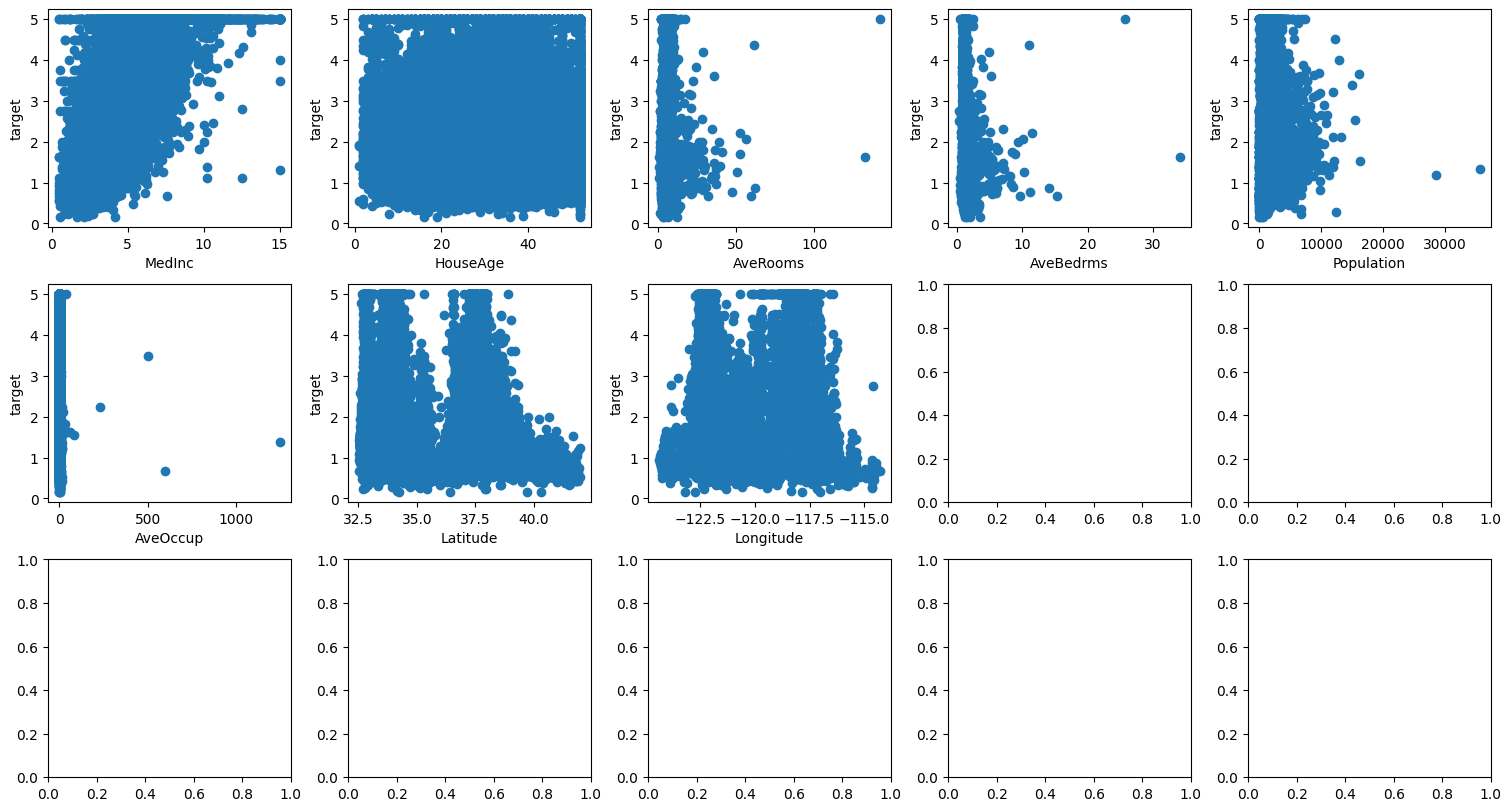

In [10]:
# visualize the relationship between the features and the response using scatterplots
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#sns.pairplot(df_boston, x_vars=boston.feature_names, y_vars='target')

fig, axes = plt.subplots(3, 5,figsize=[15,8],constrained_layout=True)
axes = axes.flatten()
i=0
for x in df_housing.columns[:-1]:
    plt.sca(axes[i]) # set the current Axes
    plt.scatter(df_housing[x],df_housing.target)
    plt.xlabel(x)
    plt.ylabel("target")
    i+=1

plt.show()

In [11]:
#Predicting house value from a single feature
X_rooms = df_housing[['MedInc']]
y = df_housing[['target']]

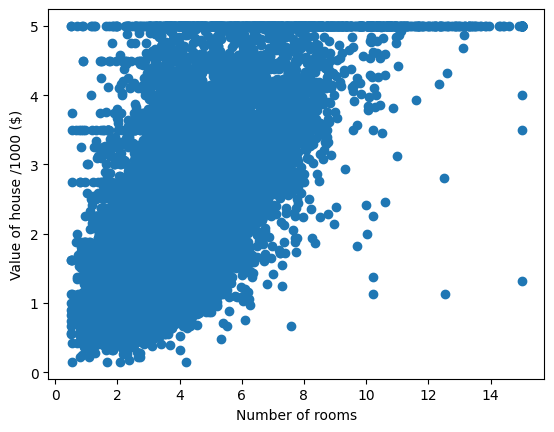

In [12]:
#Let's plot house value as a function of number of rooms using matplotlib's plt dot scatter
%matplotlib inline
plt.scatter(X_rooms,y)
plt.ylabel('Value of house /1000 ($)') #labeling the y label
plt.xlabel('Number of rooms') #labeling the x label
plt.show()
#more rooms lead to higher prices

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_rooms,y,
                                                    test_size=0.3,
                                                    random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression #Ordinary Least Squares

# Create linear regression object
regr = LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)


LinearRegression()

In [15]:
#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.linear_model import LinearRegression #Ordinary Least Squares
import numpy as np

regressor = LinearRegression()
# fit_intercept : boolean, optional, default True
#    whether to calculate the intercept for this model.

#normalize : boolean, optional, default False
#    This parameter is ignored when fit_intercept is set to False.
#    If True, the regressors X will be normalized before regression.

#copy_X : boolean, optional, default True
#    If True, X will be copied; else, it may be overwritten.


# Create linear regression object
# Train the model using the training sets
# regressor.fit(X_train, y_train)

#DEFINE YOUR GRIDSEARCH

from sklearn.model_selection import GridSearchCV
parameters = {} #'normalize':[True,False]

gs = GridSearchCV(regressor, parameters, cv=3) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)


In [16]:
#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.473598 using {}
0.473598 (0.002864) with: {}


In [17]:
#Returns the coefficient of determination R^2 of the prediction.
#Explained variance score: 1 is perfect prediction
gs.score(X_test, y_test)

0.47293192589970245

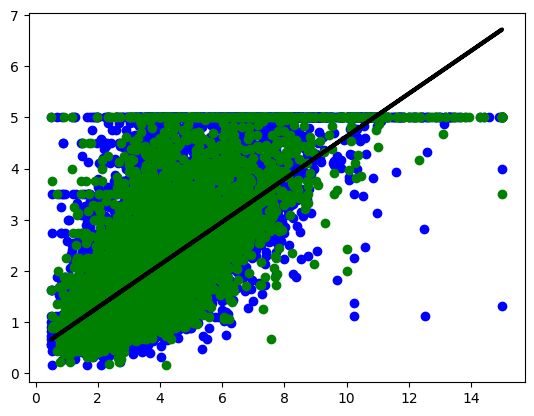

In [18]:
plt.scatter(X_train,y_train, color='blue')
plt.scatter(X_test, y_test, color='green')
plt.plot(X_test, gs.predict(X_test), color='black',linewidth=3)
plt.show()

In [19]:
# Estimated coefficients for the linear regression problem.
print('Coefficients: ', gs.best_estimator_.coef_)

#Independent term in the linear model.
print('Intercept: ', gs.best_estimator_.intercept_)

Coefficients:  [[0.41819327]]
Intercept:  [0.44794966]


In [20]:
error_train=gs.predict(X_train)-y_train
error_test=gs.predict(X_test)-y_test

error_train.describe()


,target
count,1.444800e+04
mean,7.475256e-17
std,8.397532e-01
min,-4.343006e+00
25%,-3.718135e-01
50%,1.713190e-01
75%,5.596494e-01
max,5.407891e+00


In [21]:
error_test.describe()


,target
count,6192.000000
mean,-0.006400
std,0.831786
min,-4.343006
25%,-0.371149
50%,0.161112
75%,0.553464
max,3.220891


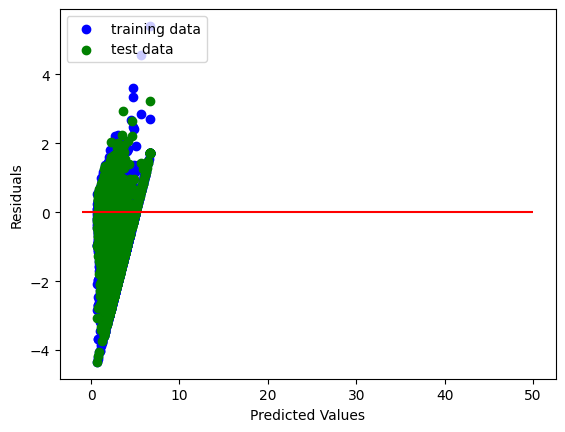

In [22]:
plt.scatter(gs.predict(X_train),error_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),error_test, c="g", label="test data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-1, xmax=50, color="r")
plt.show()

## Normality Test

In [23]:
nb_error_train = np.array(error_train).flatten()

In [24]:
# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(error_train)

scaled_error_train = scaler.transform(error_train).flatten()

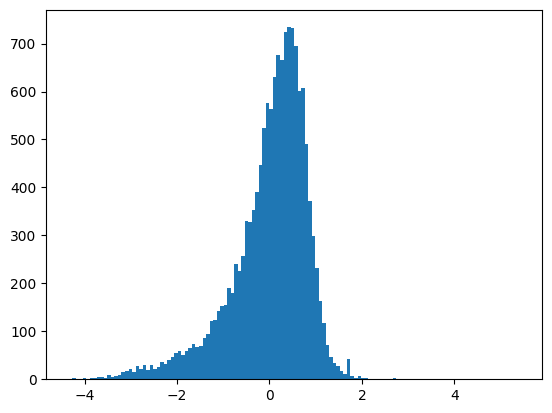

In [25]:
plt.hist(nb_error_train, bins='auto')
plt.show()

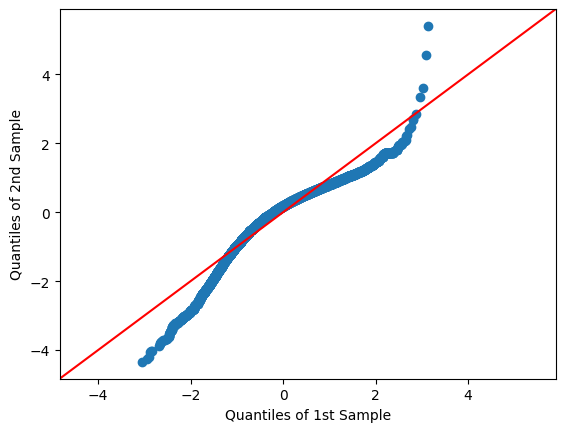

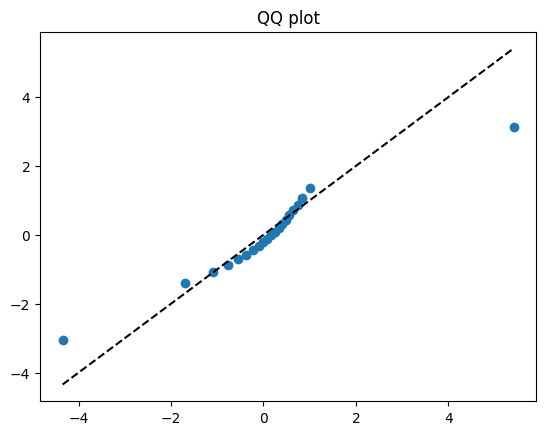

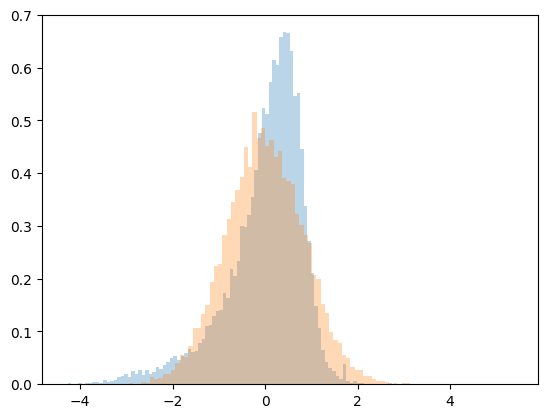

In [26]:
import numpy as np
import scipy
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot_2samples
from matplotlib import pyplot as plt

# We test a exponential distribution
dist = getattr(scipy.stats, 'norm')
param = dist.fit(nb_error_train)

err_mean=param[-2]
err_std=param[-1]

# We generate a sample of size  len(mr_scaled) of data distributed according to distribution dist
# The function rvs generates a sample with distribution dist with mean loc and std scale
test_dist = dist.rvs(*param[0:-2],loc=param[-2], scale=param[-1],size = len(error_train))
test_dist.sort()

# qq-plot using statsmodels
qqplot_2samples(test_dist,np.array(error_train).flatten(),  line='45')
plt.show()

# We create the percentiles for both distributions
percs = np.linspace(0,100,21)
q_a = np.percentile(error_train, percs)
q_b = np.percentile(test_dist, percs)

# and generate the QQ-plot
plt.plot(q_a,q_b, ls="", marker="o")
plt.title("QQ plot")
x = np.linspace(np.min((q_a.min(),q_b.min())), np.max((q_a.max(),q_b.max())))
plt.plot(x,x, color="k", ls="--")
plt.show()

plt.hist(error_train,alpha=.3, density=True,bins='auto')
plt.hist(test_dist,alpha=.3, density=True,bins='auto')
plt.show()

In [27]:
# Kolmogorov-Smirnov Test
#    Test the distribution G(x) against a given distribution F(x).
#    Under the null hypothesis the two distributions are identical, G(x)=F(x).

from scipy import stats
stats.kstest(scaled_error_train,"norm")
#stats.kstest(nb_error_train,test_dist)

KstestResult(statistic=np.float64(0.09913304241721127), pvalue=np.float64(4.744435381725048e-124), statistic_location=np.float64(-0.12764211875228967), statistic_sign=np.int8(-1))

In [28]:
# D’Agostino Test
#    Under the null hypothesis that the distributions follows a normal distribution.

stats.normaltest(scaled_error_train)

NormaltestResult(statistic=np.float64(3008.116582694672), pvalue=np.float64(0.0))

In [29]:
# Shapiro test for normality
from scipy import stats
stats.shapiro(scaled_error_train)

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14448.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9202898051706881), pvalue=np.float64(2.9061685255027313e-65))